In [1]:
import glob
import os
import numpy as np
import pandas as pd

In [2]:
from larch.io import read_ascii
from larch.xafs import pre_edge

In [3]:
def process_xanes_file(fname, window_eV=30):
    dat = read_ascii(fname)

    dat.energy = dat.qexafs_energy
    dat.mu = dat.lni0it

    # sort by increasing energy
    idx = np.argsort(dat.energy)
    dat.energy = dat.energy[idx]
    dat.mu     = dat.mu[idx]

    # run pre-edge subtraction + normalisation
    pre_edge(dat.energy, dat.mu, group=dat)

    # two E0 definitions
    e0_deriv = dat.e0
    e0_half  = e0_half_from_norm(dat, window_eV=window_eV)

    return dat, e0_deriv, e0_half

In [4]:
def e0_half_from_norm(group, window_eV=30):
    energy = group.energy
    mu_norm = group.norm
    e0_guess = group.e0  # from pre_edge

    # restrict to around the edge
    mask = (energy > e0_guess - window_eV) & (energy < e0_guess + window_eV)
    E_win = energy[mask]
    mu_win = mu_norm[mask]

    # find energy where mu_norm is closest to 0.5
    idx = np.argmin(np.abs(mu_win - 0.5))
    return E_win[idx]

In [5]:
def time_weighted_avg(time, values):
    time = np.asarray(time)
    values = np.asarray(values)
    
    dt = np.empty_like(time)
    dt[0] = 0.0                 # first entry is zero
    dt[1:] = np.diff(time)      # dt[i] = time[i] - time[i-1]
    
    return (values * dt).sum() / dt.sum()

In [6]:
def last_index_before(target, times):
    j = np.searchsorted(times, target, side='right') - 1
    return max(j, 0)

In [7]:
from datetime import datetime

def get_start_datetime(fname):
    with open(fname, 'r') as f:
        # read first few lines to find the Date: line
        for _ in range(5):   # header is near the top
            line = f.readline()
            if 'Date:' in line:
                # split at 'Date:' and strip
                date_str = line.split('Date:')[1].strip()
                break
        else:
            raise ValueError(f"No Date line found in {fname}")
    
    # Example date_str: 'Sun, 8 May 2022 20:46:15 BST'
    # %a = weekday, %d/%e = day, %b = month, %Y = year, %H:%M:%S = time, %Z = tz
    # %Z won't always understand 'BST' portably, so simplest is to ignore %Z.
    # Drop the last token (BST) and parse the rest:
    parts = date_str.rsplit(' ', 1)   # ['Sun, 8 May 2022 20:46:15', 'BST']
    date_no_tz = parts[0]

    dt = datetime.strptime(date_no_tz, '%a, %d %b %Y %H:%M:%S')
    return dt

In [8]:
data_dir = 'data'
filepaths = sorted(glob.glob(os.path.join(data_dir, '*.dat')))

# get start times for all files in order
start_times = [get_start_datetime(fname) for fname in filepaths]

# duration for file i = start_time[i+1] - start_time[i]

scan_durations_s = []

for i, fname in enumerate(filepaths):
    if i < len(filepaths) - 1:
        dt = start_times[i+1] - start_times[i]
        duration_s = dt.total_seconds()   # float seconds
    else:
        # fallback for last file
        dat, _, _ = process_xanes_file(fname)
        duration_s = np.sum(dat.time)
        
    scan_durations_s.append(duration_s)

In [9]:
ec = pd.read_csv('data/LNO_freshcell_highvoltage_C01.csv')

# Rename columns for convenience
ec.columns = ['time_s', 'voltage_V', 'current_mA', 'capacity_mAh']

ec_times = ec['time_s'].values  # sorted ascending

In [11]:
rows = []
global_t = 0.0

for i, fname in enumerate(filepaths):
    dat, e0_deriv, e0_half = process_xanes_file(fname)

    scan_time = scan_durations_s[i]
    
    t_start = global_t
    t_end = global_t + scan_time
    global_t = t_end    # advance clock for next scan

    base = os.path.basename(fname)

    # Only process scans for the LNO sample
    if 'LNO_fresh_Ni_1' not in base:
        continue

    # EC indices for this LNO scan window
    j_start = last_index_before(t_start, ec_times)
    j_end   = last_index_before(t_end,   ec_times)

    # EC window for this scan: from previous j_start to new j_end
    ec_window = ec.iloc[j_start:j_end+1]

    # time-averaged voltage and capacity
    v_avg = time_weighted_avg(ec_window['time_s'], ec_window['voltage_V'])
    q_avg = time_weighted_avg(ec_window['time_s'], ec_window['capacity_mAh'])
    
    rows.append({
        'scan_index': len(rows) + 1,       # index among LNO scans
        'file': base,
        't_start_s_global': t_start,
        't_end_s_global':   t_end,
        'scan_time_s':      scan_time,
        'E0_deriv': e0_deriv,
        'E0_half':  e0_half,
        'V_avg':            v_avg,
        'Q_avg':            q_avg
    })

pd.set_option('display.max_rows', 100)
results = pd.DataFrame(rows)
results

,scan_index,file,t_start_s_global,t_end_s_global,scan_time_s,E0_deriv,E0_half,V_avg,Q_avg
0,1,538431_LNO_fresh_Ni_1.dat,0.0,140.0,140.0,8349.76,8344.73,3.340374,0.011797
1,2,538436_LNO_fresh_Ni_1.dat,600.0,741.0,141.0,8350.04,8344.73,3.716585,0.128531
2,3,538440_LNO_fresh_Ni_1.dat,1078.0,1219.0,141.0,8350.04,8345.01,3.701235,0.221377
3,4,538444_LNO_fresh_Ni_1.dat,1557.0,1698.0,141.0,8350.04,8345.01,3.697649,0.314223
4,5,538448_LNO_fresh_Ni_1.dat,2036.0,2177.0,141.0,8350.04,8345.01,3.697854,0.407555
5,6,538452_LNO_fresh_Ni_1.dat,3325.0,3466.0,141.0,8350.32,8345.01,3.705593,0.658386
6,7,538456_LNO_fresh_Ni_1.dat,3804.0,3945.0,141.0,8350.32,8345.29,3.710199,0.751719
7,8,538460_LNO_fresh_Ni_1.dat,4283.0,4423.0,140.0,8350.32,8345.29,3.716311,0.844080
8,9,538464_LNO_fresh_Ni_1.dat,4761.0,4901.0,140.0,8350.32,8345.29,3.723944,0.937414
9,10,538468_LNO_fresh_Ni_1.dat,5239.0,5380.0,141.0,8350.32,8345.29,3.733451,1.030747


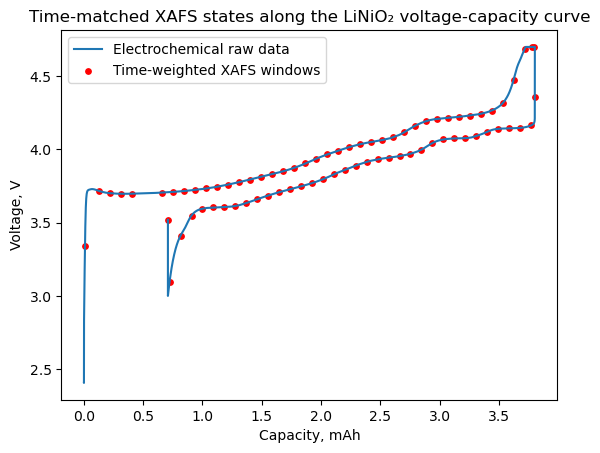

In [24]:
import matplotlib.pyplot as plt

plt.plot(ec['capacity_mAh'], ec['voltage_V'], label='Electrochemical raw data')
plt.scatter(results['Q_avg'], results['V_avg'], label='Time-weighted XAFS windows', c='red', s=15)
plt.title('Time-matched XAFS states along the LiNiO₂ voltage-capacity curve')
plt.xlabel('Capacity, mAh')
plt.ylabel('Voltage, V')
plt.legend()
plt.savefig('synchronised echem.png')
plt.show()

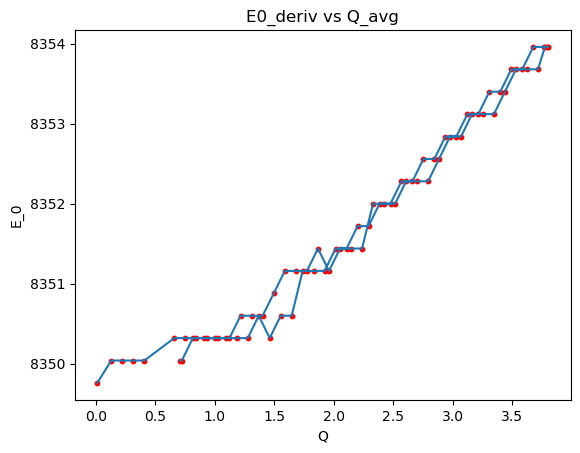

In [13]:
plt.plot(results['Q_avg'], results['E0_deriv'])
plt.scatter(results['Q_avg'], results['E0_deriv'], label='data points', c='red', s=10)
plt.title('E0_deriv vs Q_avg')
plt.xlabel('Q')
plt.ylabel('E_0')
plt.show()

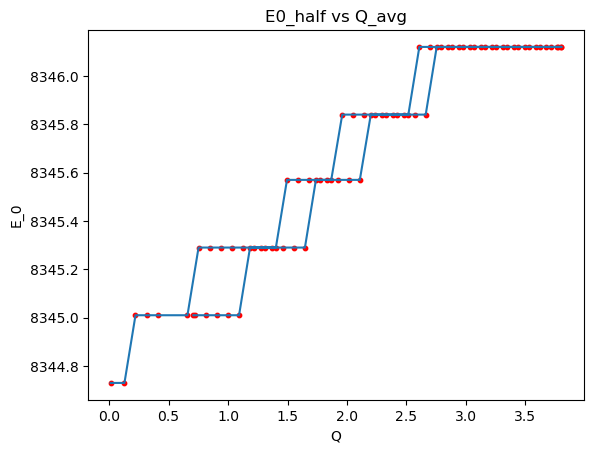

In [14]:
plt.plot(results['Q_avg'], results['E0_half'])
plt.scatter(results['Q_avg'], results['E0_half'], label='data points', c='red', s=10)
plt.title('E0_half vs Q_avg')
plt.xlabel('Q')
plt.ylabel('E_0')
plt.show()

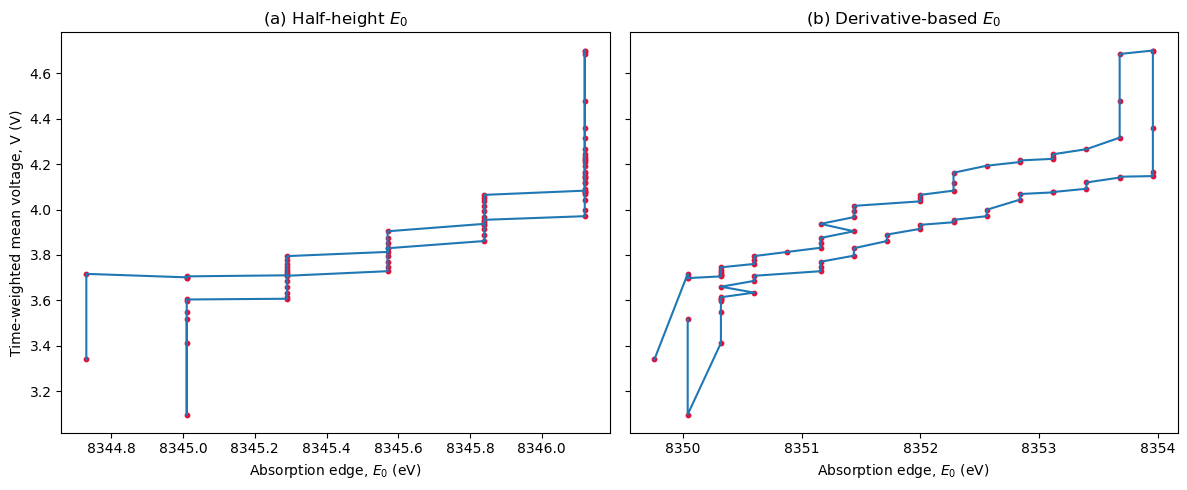

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Panel (a): half-height E0
axes[0].plot(
    results['E0_half'],
    results['V_avg']
)

axes[0].scatter(
    results['E0_half'],
    results['V_avg'],
    color='crimson',
    s=10
)

axes[0].set_title(r'(a) Half-height $E_0$')
axes[0].set_xlabel('Absorption edge, $E_0$ (eV)')
axes[0].set_ylabel('Time-weighted mean voltage, V (V)')


# Panel (b): derivative-based E0
axes[1].plot(
    results['E0_deriv'],
    results['V_avg']
)

axes[1].scatter(
    results['E0_deriv'],
    results['V_avg'],
    color='crimson',
    s=10
)

axes[1].set_title(r'(b) Derivative-based $E_0$')
axes[1].set_xlabel('Absorption edge, $E_0$ (eV)')

plt.tight_layout()

plt.savefig('E0_definitions_vs_voltage.png')

plt.show()